In [1]:
# Churn datasetini KaggleHub ile indiriyoruz

import kagglehub

dataset_path = kagglehub.dataset_download(
    "blastchar/telco-customer-churn"
)

print(dataset_path)

/kaggle/input/datasets/blastchar/telco-customer-churn


In [2]:
# Dataset dosyalarını kontrol ediyoruz

import os

print(os.listdir(dataset_path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [3]:
# Dataseti okuyoruz

import pandas as pd

df = pd.read_csv(
    dataset_path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print(df.shape)

df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 📊 Veri Analizi ve Veri Hazırlama

Bu bölümde müşteri churn veri seti analiz edilerek veri temizleme ve ön işleme adımları gerçekleştirilecektir.

In [4]:
# Veri tiplerini inceliyoruz

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Eksik veri kontrolü yapıyoruz

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Sayısal istatistikleri inceliyoruz

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# 🧹 Veri Ön İşleme

Bu bölümde kategorik veriler sayısal verilere dönüştürülerek yapay sinir ağı modeline uygun hale getirilecektir.

In [7]:
# Gereksiz sütunu siliyoruz

df.drop("customerID", axis=1, inplace=True)

In [8]:
# Churn sütununu sayısala çeviriyoruz

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [9]:
# TotalCharges sütununu numeriğe çeviriyoruz

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [10]:
# Eksik verileri kontrol ediyoruz

df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
# Eksik verileri siliyoruz

df.dropna(inplace=True)

In [12]:
# Kategorik verileri sayısala çeviriyoruz

df = pd.get_dummies(df, drop_first=True)

In [13]:
# Son hali kontrol ediyoruz

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


# 🤖 ANN Modeli

Bu bölümde yapay sinir ağı modeli oluşturularak müşteri churn tahmini gerçekleştirilecektir.

In [14]:
# X ve y değişkenlerini oluşturuyoruz

X = df.drop("Churn", axis=1)

y = df["Churn"]

In [15]:
# Train ve test verisini ayırıyoruz

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
# Verileri ölçeklendiriyoruz

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [17]:
# ANN modelini oluşturuyoruz

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

ann = Sequential()

ann.add(Dense(units=16, activation="relu"))

ann.add(Dense(units=8, activation="relu"))

ann.add(Dense(units=1, activation="sigmoid"))

2026-05-17 11:15:50.224484: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779016550.446681      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779016550.514006      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779016551.087232      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779016551.087292      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779016551.087296      16 computation_placer.cc:177] computation placer alr

In [18]:
# Modeli derliyoruz

ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

2026-05-17 11:16:12.170975: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [19]:
# Modeli eğitiyoruz

history = ann.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5526 - loss: 0.7574 - val_accuracy: 0.7733 - val_loss: 0.4591
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7659 - loss: 0.4746 - val_accuracy: 0.7947 - val_loss: 0.4321
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7927 - loss: 0.4333 - val_accuracy: 0.7991 - val_loss: 0.4250
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7957 - loss: 0.4296 - val_accuracy: 0.8080 - val_loss: 0.4202
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7945 - loss: 0.4343 - val_accuracy: 0.8071 - val_loss: 0.4165
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7910 - loss: 0.4377 - val_accuracy: 0.8080 - val_loss: 0.4138
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7997 - loss: 0.4150 - val_accuracy: 0.8116 - val_loss: 0.4117
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8174 - loss: 0.4037 - val_accuracy: 0.

In [20]:
# Test verisi üzerinde tahmin yapıyoruz

y_pred = ann.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [21]:
# ANN model performansını ölçüyoruz

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

ann_acc = accuracy_score(y_test, y_pred)

print("ANN Accuracy:", ann_acc)

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

ANN Accuracy: 0.7818052594171997
[[912 121]
 [186 188]]
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.61      0.50      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [22]:
# Görselleştirme kütüphanelerini import ediyoruz

import matplotlib.pyplot as plt

import seaborn as sns

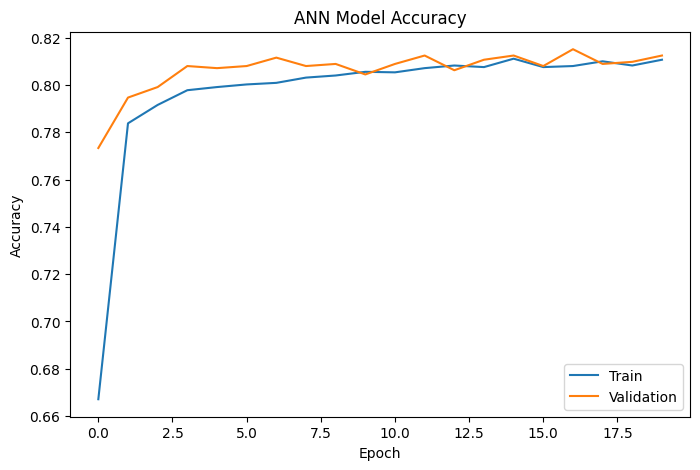

In [23]:
# Accuracy değişimini görselleştiriyoruz

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("ANN Model Accuracy")

plt.ylabel("Accuracy")

plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])

plt.show()

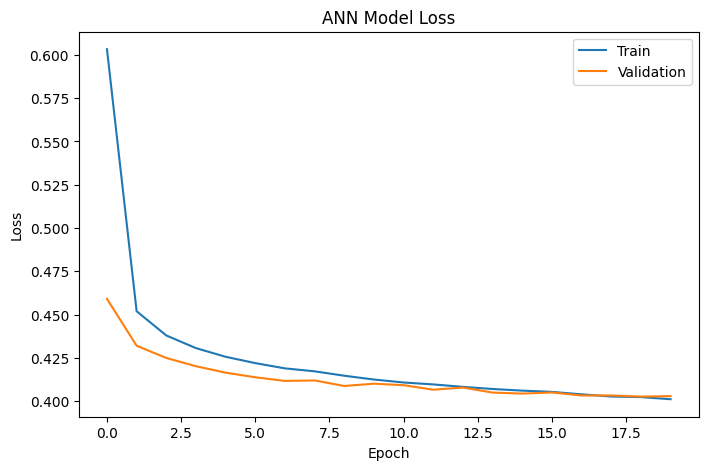

In [24]:
# Loss değişimini görselleştiriyoruz

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("ANN Model Loss")

plt.ylabel("Loss")

plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])

plt.show()

# ✅ Proje Sonuçları

Bu projede Telco Customer Churn veri seti kullanılarak yapay sinir ağı (ANN) modeli ile müşteri churn tahmini gerçekleştirilmiştir.

Proje kapsamında:

- Veri analizi yapılmıştır
- Eksik veriler temizlenmiştir
- Kategorik veriler sayısal verilere dönüştürülmüştür
- Veriler ölçeklendirilmiştir
- ANN modeli oluşturulmuştur
- Model performansı değerlendirilmiştir

Model sonuçlarına göre ANN modeli yaklaşık %78 doğruluk oranı elde etmiştir.

Bu proje sayesinde:

- Deep Learning
- Artificial Neural Networks (ANN)
- TensorFlow / Keras
- Veri ölçeklendirme
- Classification işlemleri
- Accuracy ve Loss analizi

uygulanmıştır.